# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, determine the median alternative PM2.5 data in every contiguous U.S. county for every day in 2019.

#### **Scope:** Alternative PM2.5 values in the contiguous U.S. in 2019 by U.S. county.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | USHAP\_PM2.5\_D1K\_2019\_V1.zip | Derived from research out of the Universities of Maryland and Iowa on 11/03/2025, this dataset contains 1\-kilometer resolution PM2.5 estimates in the contiguous United States for every day in the year 2019. The dataset was generated from big data \(e.g., ground\-based measurements, satellite remote sensing products, atmospheric reanalysis, and model simulations\) using artificial intelligence. The researchers show their estimates align well with physical measurements, with 0.82 cross\-validated coefficients of determination. | Paper: [https://www.thelancet.com/journals/lanplh/article/PIIS2542\-5196\(23\)00235\-8/fulltext](https://www.thelancet.com/journals/lanplh/article/PIIS2542-5196(23)00235-8/fulltext) <br> <br>  Data: <br> https://zenodo.org/records/7884640 |
| 2 | tl\_2019\_us\_county.zip | Derived from the U.S. Census Bureau on 11/30/2025, this dataset contains each of the U.S. county boundaries in shapefile format. | Data: <br>[https://www.census.gov/cgi\-bin/geo/shapefiles/index.php](https://www.census.gov/cgi-bin/geo/shapefiles/index.php) |
| 3 | State_FIPS.csv | Derived from the Federal Information Processing System (FIPS) Codes for States and Counties on 11/30/2025, this dataset contains each of the U.S. county and state's FIPS codes. FIPS codes are numbers which uniquely identify geographic areas.  The number of digits in FIPS codes vary depending on the level of geography.  State-level FIPS codes have two digits, county-level FIPS codes have five digits of which the first two are the FIPS code of the state to which the county belongs. | Data: <br>[https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt](https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt) |

#### **Conclusions:** The final dataset contains a daily median alternative PM2.5 value for each county in the contiguous United States for the year 2019. This dataset will be merged with the processed air quality monitor dataset in a subsequent analysis.



#### General Methodology

##### Steps

1. Load libraries
2. Load alternative PM2.5 dataset
3. Load US county dataset
4. Reduce the US county dataset to only contiguous US counties
5. Associate the alternative PM2.5 dataset with the contiguous US counties, grabbing the daily median value for each county in 2019
6. Export the daily median values for each county in 2019 into a csv for later analysis.

_Note: It is important that I maintain a unique identifier in the exported csv for later matching to the air quality monitor dataset_



#### Load Libraries



In [3]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))
suppressPackageStartupMessages(library(tidyterra))
suppressPackageStartupMessages(library(exactextractr))
suppressPackageStartupMessages(library(sf))
suppressPackageStartupMessages(library(lubridate))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(terra)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")
if (!require(tidyterra)) install.packages("tidyterra")
if (!require(exactextractr)) install.packages("exactextractr")
if (!require(sf)) install.packages("sf")
if (!require(sf)) install.packages("lubridate")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)
library(tidyterra)
library(exactextractr)
library(sf)
library(lubridate)

# Note: exactextractr is an R package that quickly and accurately summarizes raster values over polygonal areas, commonly referred to as zonal statistics. Unlike most zonal statistics implementations, it handles grid cells that are partially covered by a polygon. Despite this, it performs faster other packages for many real-world applications.
# https://cran.r-project.org/web/packages/exactextractr/readme/README.html


#### Load Alternative PM2.5 Dataset



In [4]:
#Purpose of Cell Block: Locate and ready Alt. PM2.5 datasets 
setwd("/home/user/capstone/A_data")
altPM25_files <- list.files("C_raw_data/alternative_PM25_data", pattern = "\\.nc$", full.names = TRUE) #identify the number of alt. PM2.5 files in data folder
n_distinct(altPM25_files) #count alt. PM2.5 files


#Identify the relevant variable in the alternative dataset
altpm25_var <- names(rast(altPM25_files[1]))
altpm25_var

[1] 364

[1] "PM2.5"

#### Load U.S. County Dataset



In [5]:
#Purpose of Cell Block: Load county dataset and begin preparing it to drop all features except contiguous states. We are dropping these features because our alternative air quality dataset only contains values for the contiguous US

counties <- vect("C_raw_data/census/county_boundaries/tl_2019_us_county.shp")

counties2 <- counties %>% #rename column to match with a dataset we will use to drop features
    rename(FIPS_Fix = STATEFP)

names(counties2) #confirm our rename was effective

DFcounties <- as.data.frame(counties2) #convert to dataframe so we can see visualize the state fips

states <- DFcounties %>% #organize the only portion of the dataframe in which we are interested
    arrange(desc(FIPS_Fix)) %>%
    select(FIPS_Fix)

STRstates <- states$FIPS_Fix #convert data frame to a vector string

unique(STRstates)

#Conclusion: The counties dataset is prepared to remove the excess features

[1] "FIPS_Fix" "COUNTYFP" "COUNTYNS" "GEOID"    "NAME"     "NAMELSAD"
 [7] "LSAD"     "CLASSFP"  "MTFCC"    "CSAFP"    "CBSAFP"   "METDIVFP"
[13] "FUNCSTAT" "ALAND"    "AWATER"   "INTPTLAT" "INTPTLON"

[1] "78" "72" "69" "66" "60" "56" "55" "54" "53" "51" "50" "49" "48" "47" "46"
[16] "45" "44" "42" "41" "40" "39" "38" "37" "36" "35" "34" "33" "32" "31" "30"
[31] "29" "28" "27" "26" "25" "24" "23" "22" "21" "20" "19" "18" "17" "16" "15"
[46] "13" "12" "11" "10" "09" "08" "06" "05" "04" "02" "01"

In [6]:
#Purpose of Cell Block: Load the FIPS table, which we intend to use to remove the features from the counties dataset
DFfips <- DFfips <- read.csv("C_raw_data/FCC/State_FIPS.csv")

DFfips2 <- DFfips %>%
    mutate('FIPS_Fix' = str_pad(FIPS, width = 2, pad = 0)) %>%  #pad leading zero so state code always 2 char
    select(-('FIPS'))  #drop old codes

DFfips2
#Conclusion: The dataset includes FIPS for the contigous US, Hawaii, and Alaska

NAME,FIPS_Fix
<chr>,<chr>
ALABAMA,01
ALASKA,02
ARIZONA,04
ARKANSAS,05
CALIFORNIA,06
COLORADO,08
CONNECTICUT,09
DELAWARE,10
DISTRICT OF COLUMBIA,11


In [7]:
#Purpose of Cell Block: Remove the non-contiguous features from the counties dataset
contiguous_counties <- counties2 %>% #join to the FIPS dataset, keeping only the data that matches
    semi_join(DFfips2, by = "FIPS_Fix") %>%
    filter(
        FIPS_Fix != '15' & #manually remove hawaii
        FIPS_Fix != '02' #manually remove alaska
    )

n_distinct(contiguous_counties$FIPS_Fix)

DFcounties <- as.data.frame(contiguous_counties)

states <- DFcounties %>%
    arrange(desc(FIPS_Fix)) %>%
    select(FIPS_Fix)

STRstates <- states$FIPS_Fix

unique(STRstates) #confirm only contiguous FIPS remain

head(contiguous_counties)
n_distinct(contiguous_counties$COUNTYNS) #This is the variable I'll need to keep for each county to merge my output back once I'm done processing it's a unique identifier)
n_distinct(contiguous_counties$FIPS_Fix)

[1] 49

[1] "56" "55" "54" "53" "51" "50" "49" "48" "47" "46" "45" "44" "42" "41" "40"
[16] "39" "38" "37" "36" "35" "34" "33" "32" "31" "30" "29" "28" "27" "26" "25"
[31] "24" "23" "22" "21" "20" "19" "18" "17" "16" "13" "12" "11" "10" "09" "08"
[46] "06" "05" "04" "01"

FIPS_Fix,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,NA,NA,NA,A,1477652222,10690952,+41.9158651,-096.7885168
53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,NA,NA,NA,A,680962890,61582307,+46.2946377,-123.4244583
35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,NA,NA,NA,A,6016819475,29089486,+34.3592729,-104.3686961
31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NA,A,2169270569,22849484,+40.7835474,-096.6886584
31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,NA,NA,NA,A,1489645188,1718484,+40.1764918,-098.0468422
46,099,01265772,46099,Minnehaha,Minnehaha County,06,H1,G4020,NA,43620,NA,A,2089691755,18198481,+43.6674723,-096.7957261


[1] 3108

[1] 49

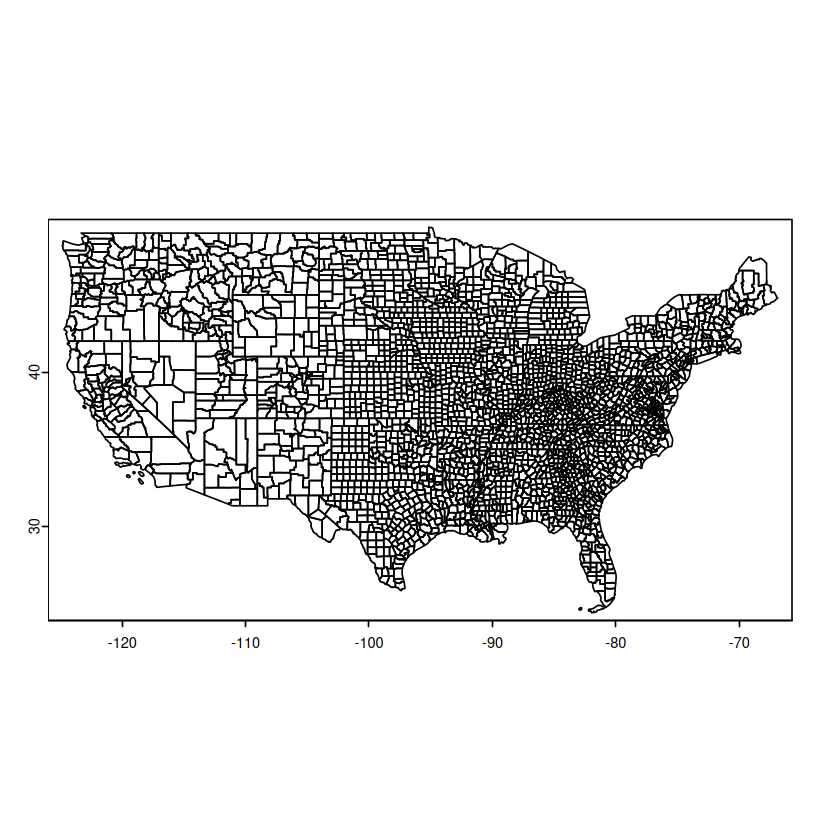

In [8]:
#Purpose of Cell Block: verify our dataset is for the contiguous US
plot(contiguous_counties)

writeVector(
  contiguous_counties,
  "D_processed_data/intermediate_scratch/contiguous_counties.gpkg",
  overwrite = TRUE
)
#Conclusion: The counties dataset was succesfully loaded and reduced to the contiguous US

#### Identify the Daily Median Alternative PM2.5 Value Location in Each Contiguous U.S. County



In [9]:
##Purpose of Cell Block: Identify, for each county and each day, the county-level median PM2.5 value using zonal statistics. Results are written to daily checkpoint files to support restartable processing. Final outputs are later combined into a year-level dataset.

#BEGIN FUNCTION: EXTRACT DATE
get_date_from_filename <- function(filepath) {
    str_extract(basename(filepath), "[0-9]{8}")
}
#END FUNCTION: EXTRACT DATE

#BEGIN FUNCTION: CHECKPOINT FILENAME AND PATH
checkpoint_path <- function(AltPM25_file) {
    date_str <- get_date_from_filename(AltPM25_file)
    file.path(checkpoint_dir, paste0("median_county_", date_str, ".csv"))
}
#END FUNCTION: CHECKPOINT FILENAME AND PATH

counties_sf0 <- if (inherits(contiguous_counties, "sf")) contiguous_counties else st_as_sf(contiguous_counties)

checkpoint_dir <- "D_processed_data/intermediate_scratch/checkpoints"

existing_checkpoints <- list.files( #feed the checkpoint filepaths into a string to check the last successfull export
  checkpoint_dir,
  pattern = "^median_county_[0-9]{8}\\.csv$",
  full.names = FALSE
)

completed_dates <- str_extract(existing_checkpoints, "[0-9]{8}") #extract dates from the checkpoint filepaths

all_dates <- get_date_from_filename(altPM25_files) #run get date function on all PM2.5 files

altPM25_files_todo <- altPM25_files[!(all_dates %in% completed_dates)] #extract all files that are not in the checkpoint filepaths

#check the total number of files versus the files i still need to work on
length(altPM25_files)
length(altPM25_files_todo) 

#check the first file that will be work on
head(get_date_from_filename(altPM25_files_todo), n=1)

n_days <- length(altPM25_files) #used for assessing progress

day_counter <- length(altPM25_files) - length(altPM25_files_todo)

for (AltPM25_file in altPM25_files_todo) { #iterate each AltPM25_file (i.e., day iterator)...
    
    day_counter <- day_counter + 1

    cat(
        sprintf(
            "\nProcessing day %d of %d: %s\n",
            day_counter,
            n_days,
            basename(AltPM25_file)
            )
        )

    flush.console()    
    
    rastAltPM25_file <- rast(AltPM25_file) #read in the raster from the day dataset above
    
    counties_sf <- st_transform(counties_sf0, crs(rastAltPM25_file)) #using our read in raster, reproject counties to align coordinate reference systems
    
    county_median <- exact_extract(rastAltPM25_file, counties_sf, "median") #use zonal stats to extract the median PM2.5 value for each county on day[AltPM25_file]
    
    daily_results <- tibble( #create container to hold one day of results
        COUNTYNS = counties_sf$COUNTYNS,
        county_row = seq_len(nrow(counties_sf)),
        county_daily_median = county_median
    )   
        
    daily_results <- daily_results %>%
        mutate(file = AltPM25_file) #create a new column that tracks the filepath used

    checkpoint_csv <- checkpoint_path(AltPM25_file) #run function to translate the current raster filepath to checkpoint filepath
    
    tmp_csv <- paste0(checkpoint_csv, ".tmp") #concat a .tmp extension, necessary to minimize risk the program partially exported a file when cocalc shutdown
    
    write_csv(daily_results, tmp_csv) #write the temp file to checkpoint folder
    
    file.rename(tmp_csv, checkpoint_csv) #rename the temp file as the final filename
}
    

[1] 364

[1] 0

character(0)

In [10]:
#Purpose of Cell Block: Grab all per-day checkpoint CSV files produced by the median county extraction workflow above, read each file into memory, and combine them into a single multi-day dataset. Then validate number of unique day files represented in the combined results, ensuring that all expected daily outputs were successfully merged.

getwd()
setwd("/home/user/capstone/A_data")
checkpoint_files <- list.files( #create vector of checkpoint files
    "D_processed_data/intermediate_scratch/checkpoints", pattern = "\\.csv$", full.names = TRUE) 

print("Number of days in checkpoint folder")
n_distinct(checkpoint_files) #count alt. PM2.5 files
  
all_days_list <- list() #initialize list for storing PM2.5 files

for (i in seq_along(checkpoint_files)) { #for each checkpoint file in the vector above...
    all_days_list[[i]] <- read_csv( #read in csv[i] as a tibble (see next row)
        checkpoint_files[i], 
        show_col_types = FALSE 
    )
}

results_all_days <- bind_rows(all_days_list) #bind tibbles created in the for loop above

head(results_all_days) #tentatively confirm bind worked
file_check <- n_distinct(results_all_days$file)
print("Number of days in bound dataset")
file_check

#Conclusion: Dataset was successfully generated

[1] "/home/user/capstone/A_data"

[1] "Number of days in checkpoint folder"


[1] 364

COUNTYNS,county_row,county_daily_median,file
<chr>,<dbl>,<dbl>,<chr>
00835841,1,4.707248,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc
01513275,2,10.101170,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc
00933054,3,3.823801,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc
00835876,4,5.467629,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc
00835886,5,3.469285,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc
01265772,6,3.978033,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc


[1] "Number of days in bound dataset"


[1] 364

COUNTYNS,county_row,county_daily_median,file,date
<chr>,<dbl>,<dbl>,<chr>,<date>
00835841,1,4.707248,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01
01513275,2,10.101170,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01
00933054,3,3.823801,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01
00835876,4,5.467629,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01
00835886,5,3.469285,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01
01265772,6,3.978033,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01


[1] "Variables with Missing Data (Percent):"


variable,missing_percent
<chr>,<dbl>


[1] "Shape of Data Assessment: PM2.5"


[1] "Outlier Assessment: PM2.5"


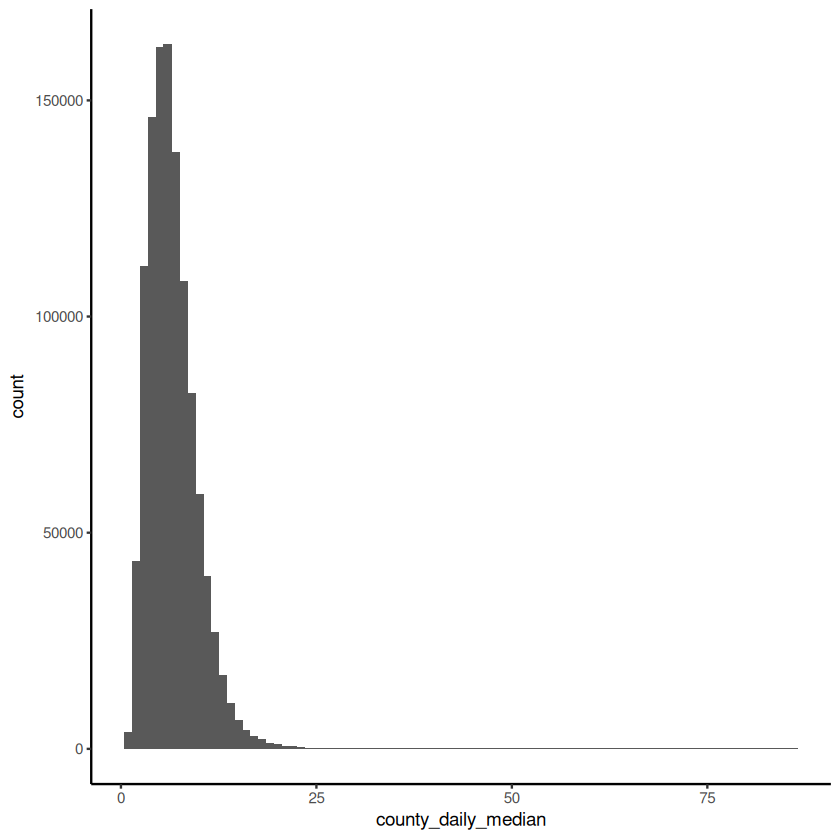

date,n_median_cells
<date>,<int>
2019-01-01,3108
2019-01-02,3108
2019-01-03,3108
2019-01-04,3108
2019-01-05,3108
2019-01-06,3108


[1] 3108


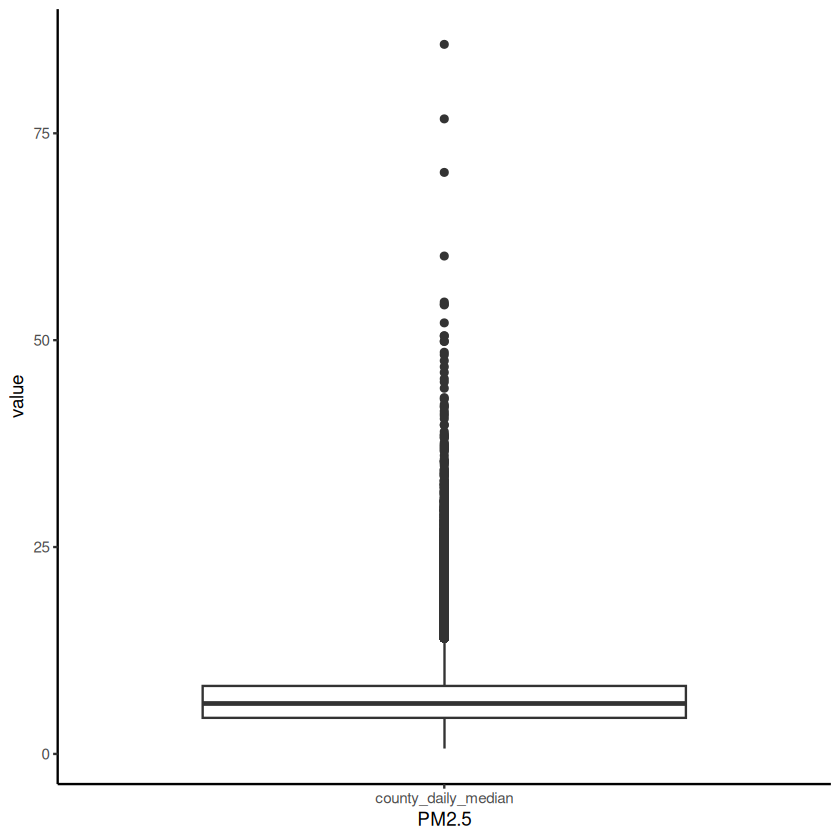

In [11]:
#Purpose of Cell Block: Create a new column with the date associated with values, check the dataset for mistakes.

#BEGIN FUNCTION: GRAB THE DATE FROM THE FILEPATH AND PLACE IT IN A NEW COLUMN 
get_date_from_checkpoint <- function(path) {
  str_extract(basename(path), "[0-9]{8}")
}
#END FUNCTION: GRAB THE DATE FROM THE FILEPATH AND PLACE IT IN A NEW COLUMN

dates_vec <- lapply(checkpoint_files, get_date_from_checkpoint) |> unlist()

results_all_days <- bind_rows(
    lapply(seq_along(checkpoint_files), function(k) {
        read_csv(checkpoint_files[k], show_col_types = FALSE) %>%
        mutate(date = dates_vec[k]) 
    })
)

results_all_days$date <- ymd(results_all_days$date) #update date column to date format

head(results_all_days)

#Visualize missingness
print("Variables with Missing Data (Percent):")
results_all_days %>%
    summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "missing_percent")  %>%
    filter(missing_percent > 0)
  
#describe shape
print("Shape of Data Assessment: PM2.5")
results_all_days %>%
    ggplot(aes(x=county_daily_median)) +
    geom_histogram(binwidth = 1) +
    theme_classic()

#Look for outliers
print("Outlier Assessment: PM2.5")
results_all_days %>%
    pivot_longer(c(county_daily_median), names_to="PM2.5", values_to="value") %>%
    ggplot(aes(x=PM2.5, y=value)) +
    geom_boxplot() +
    theme_classic()

#Count number of median values to confirm dataset is accurate (looking for unusual values) 
counts_by_date <- results_all_days %>%
    summarise(
        n_median_cells = sum(!is.na(county_daily_median)),
        .by = date
  )

head(counts_by_date)
print(mean(counts_by_date$n_median_cells))

#Conclusion: The count of non-missing values 3108 matches the average non-missing values 3108, indicating each day has the total expected values

In [12]:
#Purpose of Cell Block: Export daily median county values with associated dates for later comparison to air monitors 

final_output_path <- "D_processed_data/alternative_PM25_data/county_daily_median_processed_v03.csv"
write_csv(results_all_days, final_output_path)

#Conclusion: Daily median county values were successfully exported